In [ ]:
# Install Stim, PyMatching, and Qiskit
!pip install --quiet stim pymatching qiskit matplotlib
#We need to ensure we have things that can't be assumed to be 'natively' in Python.


In [ ]:
import stim
#This simulates quantum circuits but it's much more specialised than qiskit_aer.
#Stim simulates stabilizer circuits, which are a subset of quantum circuits where gates are Clifford operations
#It will be used instead of qiskit_aer because it'll make life MUCH faster and less cumbersome.
import pymatching
#PyMatching implements a classical algorithm: a minimum-weight perfect matching (MWPM) decoder.
#It takes the syndrome data (from Stim or another source), constructs a graph representing possible errors and their likelihoods, finds the most probable set of qubit errors that would lead to the observed syndrome and outputs a correction pattern to fix the errors.
import numpy as np
import matplotlib.pyplot as plt
#Setting up the surface code and introducing the errors will use stim.
#The syndromes will then be put into PyMatching to get corrections.


In [ ]:
# Distance of the surface code
d = 3

# Build the Stim surface code circuit
circuit = stim.Circuit()
#This is stim's equivalent of QuantumCircuit() in qiskit_aer
detectors = []
#This empty list will get filled up as things get going.

# Define qubit grid: d x d
# Stim provides a convenient way to make repeated stabilizers
# We'll just do a simple example: X- and Z-stabilizers on a 3x3 grid

# Qubit IDs for a 3x3 lattice
data_qubits = np.arange(d*d)

# Example: add X stabilizers (plaquettes)
# Each X stabilizer acts on 4 neighboring qubits (except edges)
# Here we will manually add one X stabilizer as a simple demo
circuit.append_operation("H", [0])  # Hadamard for X-measurement
circuit.append_operation("CNOT", [0,1])
circuit.append_operation("CNOT", [0,3])
circuit.append_operation("M", [0])  # Measure ancilla
#circuit.append_operation(operation_name, targets, args=None) is stim. stim.Circuit() objects can be subjected to it.
#Gates, operations etc. can be applied using it.


In [ ]:
# Add a single X error on qubit 1
circuit.append_operation("X", [1])


In [ ]:
# Convert Stim circuit to a detection event simulator
detector_sampler = circuit.compile_detector_sampler()
#What does .compile_detector_sampler() do?
#Converts the Stim circuit into a highly efficient C++ simulation engine.
#This can sample detection events (syndromes) very quickly

# Sample detection events
num_shots = 10
detection_events = detector_sampler.sample(shots=num_shots)
#What does .sample(shots=5) do?
#Actually runs the simulation.
#Returns detection events for the specified number of shots.

print("Detection events shape:", detection_events.shape)
print("First detection events:\n", detection_events[0])


Detection events shape: (10, 0)
First detection events:
 []


In [ ]:
import stim
import pymatching

# Suppose `circ` is your Stim surface code circuit
# e.g., a distance-3 rotated surface code with repetitions
circ = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    rounds=3,
    distance=3,
    after_clifford_depolarization=0.001
)

# Compile detector sampler
detector_sampler = stim.CompiledDetectorSampler(circ)

# Export a detector error model
dem = circ.detector_error_model(decompose_errors=True)

# Convert to PyMatching
matching_graph = pymatching.Matching.from_detector_error_model(dem)

# Sample syndromes
syndromes = detector_sampler.sample(shots=5)

# Decode the first syndrome
correction = matching_graph.decode(syndromes[0])
print("Syndrome:", syndromes[0])
print("Correction:", correction)



Syndrome: [False False False False False False False False False False False False
 False False False False False False False False False False False False]
Correction: [0]


/tmp/ipython-input-2550774978.py:1: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(detection_events, cmap='Greys', interpolation='none')


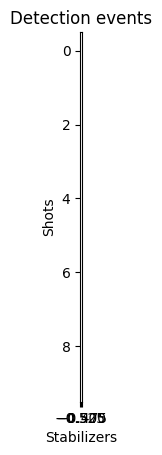

In [ ]:
plt.imshow(detection_events, cmap='Greys', interpolation='none')
plt.xlabel("Stabilizers")
plt.ylabel("Shots")
plt.title("Detection events")
plt.show()
